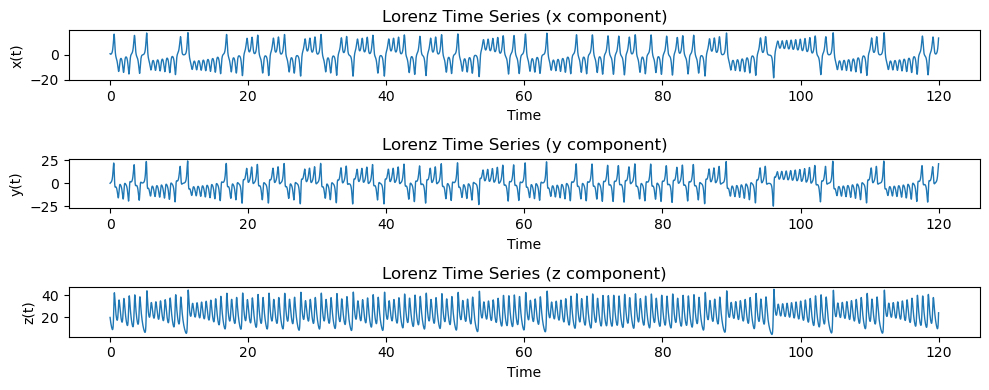

In [28]:
import numpy as np
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

# Lorenz system
def lorenz(t, state, sigma=10.0, beta=8/3, rho=28.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

# Time grid
t_start, t_end = 0.0,120.0
dt = 0.01
t_eval = np.arange(t_start, t_end, dt)

# Initial condition
y0 = [1.0, 0.0, 20.0]

# Solve ODE
sol = solve_ivp(lorenz, (t_start, t_end), y0, t_eval=t_eval, rtol=1e-9, atol=1e-12)

# Time series (use x as observed scalar series for Takens embedding)
t = sol.t
x, y, z = sol.y


# Quick plot of the observed series
fig, axs = plt.subplots(3, 1, figsize=(10, 4))
axs[0].plot(t, x, lw=1)
axs[0].set_xlabel("Time")
axs[0].set_ylabel("x(t)")
axs[0].set_title("Lorenz Time Series (x component)")
axs[1].plot(t,y,  lw=1)
axs[1].set_xlabel("Time")
axs[1].set_ylabel("y(t)")
axs[1].set_title("Lorenz Time Series (y component)")
axs[2].plot(t, z, lw=1)
axs[2].set_xlabel("Time")
axs[2].set_ylabel("z(t)")
axs[2].set_title("Lorenz Time Series (z component)")

plt.tight_layout()
plt.show()

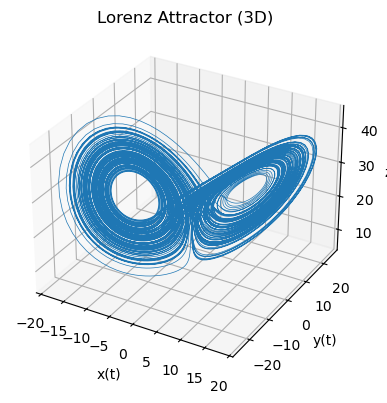

In [42]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z, lw=0.5)

ax.set_xlabel("x(t)")
ax.set_ylabel("y(t)")
ax.set_zlabel("z(t)")
ax.set_title("Lorenz Attractor (3D)")

plt.tight_layout()
plt.show()

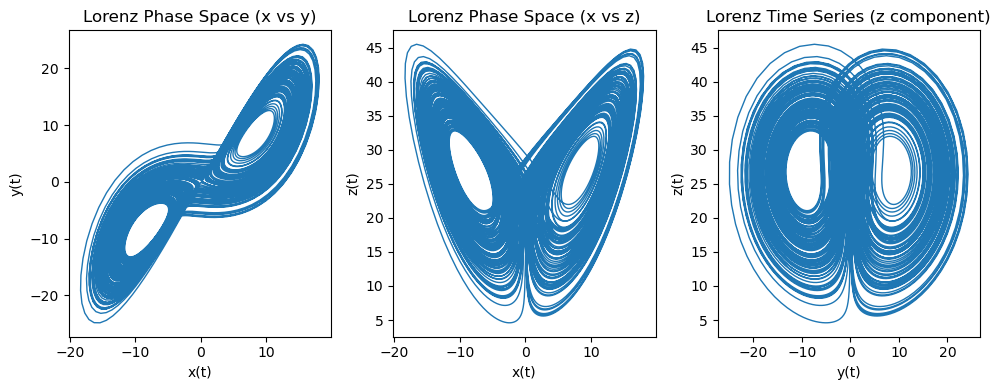

In [44]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))
axs[0].plot( x,y, lw=1)
axs[0].set_xlabel("x(t)")
axs[0].set_ylabel("y(t)")
axs[0].set_title("Lorenz Phase Space (x vs y)")
axs[1].plot(x, z, lw=1)
axs[1].set_xlabel("x(t)")
axs[1].set_ylabel("z(t)")
axs[1].set_title("Lorenz Phase Space (x vs z)")
axs[2].plot(y, z, lw=1)
axs[2].set_xlabel("y(t)")
axs[2].set_ylabel("z(t)")
axs[2].set_title("Lorenz Phase Space (y vs z)")
axs[2].set_ylabel("z(t)")
axs[2].set_title("Lorenz Time Series (z component)")

plt.tight_layout()
plt.show()

## Delay plotting

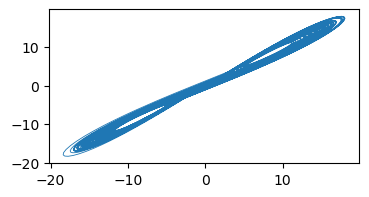

In [46]:
ts=x
tau=2
plt.figure(figsize=(4, 2))
plt.plot( ts[:-tau], ts[tau:], lw=0.6)


Takens embedded shape: (11991, 4)


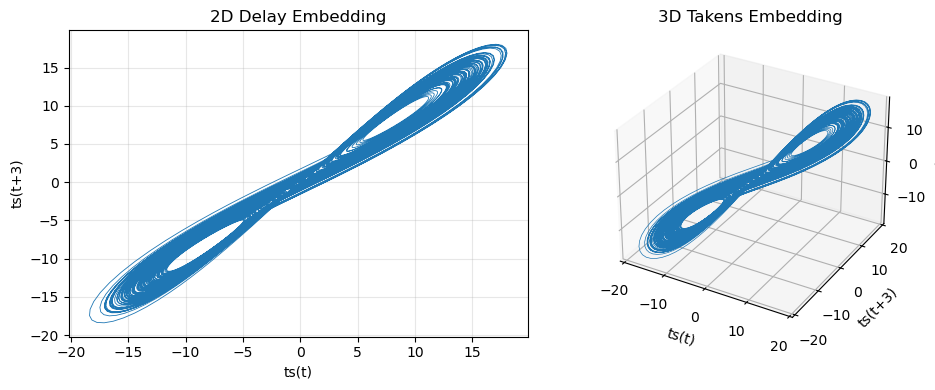

In [38]:
# Takens embedding of the observed scalar series `ts`
m = 4  # embedding dimension
N = len(ts) - (m - 1) * tau

if N <= 0:
    raise ValueError("Time series is too short for the chosen tau and embedding dimension.")

takens_ts = np.column_stack([ts[i * tau : i * tau + N] for i in range(m)])

print("Takens embedded shape:", takens_ts.shape)  # (N, m)

# Quick visualization
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(takens_ts[:, 0], takens_ts[:, 1], lw=0.6)
ax1.set_xlabel("ts(t)")
ax1.set_ylabel(f"ts(t+{tau})")
ax1.set_title("2D Delay Embedding")
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(takens_ts[:, 0], takens_ts[:, 1], takens_ts[:, 2], lw=0.5)
ax2.set_xlabel("ts(t)")
ax2.set_ylabel(f"ts(t+{tau})")
ax2.set_zlabel(f"ts(t+{2*tau})")
ax2.set_title("3D Takens Embedding")

plt.tight_layout()
plt.show()

# Takens Embedding (Short Intro)

Takens embedding is a method for reconstructing the hidden state space of a dynamical system from a single observed time series.  
Instead of measuring all system variables, it builds vectors of delayed samples:

$$
\mathbf{y}(t) = [x(t), x(t-\tau), x(t-2\tau), \dots, x(t-(m-1)\tau)]
$$

where $\tau$ is the delay and $m$ is the embedding dimension.  
Under suitable conditions, this reconstructed space preserves the geometry of the original dynamics, making it useful for analyzing chaos, attractors, and nonlinear time-series structure.


See this: https://verzep.github.io/Takens/

In [ ]:
# Create a delay embedding
def delay_embedding(data, d, tau):
    N = len(data)
    indices = np.arange(d) * tau + np.arange(N - (d - 1) * tau)[:, None]
    embedded_data = data[indices]
    return embedded_data